### ✅ Полный benchmark «До vs После .persist()» с таймерами
Вот готовый скрипт, который ты можешь запустить прямо сейчас. Он автоматически покажет разницу в скорости и запишет результаты в reports/benchmark_persist.csv + красивый график — идеальный артефакт для раздела Scalability в твоём портфолио.

2026-03-03 23:56:34 DESKTOP-1G5G75V __main__[5660] INFO 🚀 Запуск benchmark: Dask без persist vs с persist
c:\ProgramData\miniconda\envs\dist-churn-pred-env\Lib\site-packages\distributed\node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 52755 instead
  warnings.warn(
2026-03-03 23:56:39 DESKTOP-1G5G75V __main__[5660] INFO === ТЕСТ 1: Без .persist() ===
2026-03-03 23:56:48 DESKTOP-1G5G75V __main__[5660] INFO Операция 1: missing → 8.98 сек
2026-03-03 23:57:01 DESKTOP-1G5G75V __main__[5660] INFO Операция 2: describe → 12.15 сек
2026-03-03 23:57:08 DESKTOP-1G5G75V __main__[5660] INFO Операция 3: sample_5pct → 7.43 сек
2026-03-03 23:57:08 DESKTOP-1G5G75V __main__[5660] INFO === ТЕСТ 2: С .persist() ===
2026-03-03 23:57:16 DESKTOP-1G5G75V __main__[5660] INFO Операция 1: missing → 7.54 сек (после persist)
2026-03-03 23:57:18 DESKTOP-1G5G75V __main__[5660] INFO Операция 2: describe → 2.73 сек (после persist)
2026-0


📊 BENCHMARK РЕЗУЛЬТАТЫ:
          Operation  Без_persist_sec  С_persist_sec  Speedup
0           missing             8.98           7.54      1.2
1          describe            12.15           2.73      4.5
2       sample_5pct             7.43           0.44     16.8
TOTAL  persist_time             0.05           0.00      0.0


2026-03-03 23:57:20 DESKTOP-1G5G75V __main__[5660] INFO ✅ График speedup сохранён: reports/benchmark_persist.png


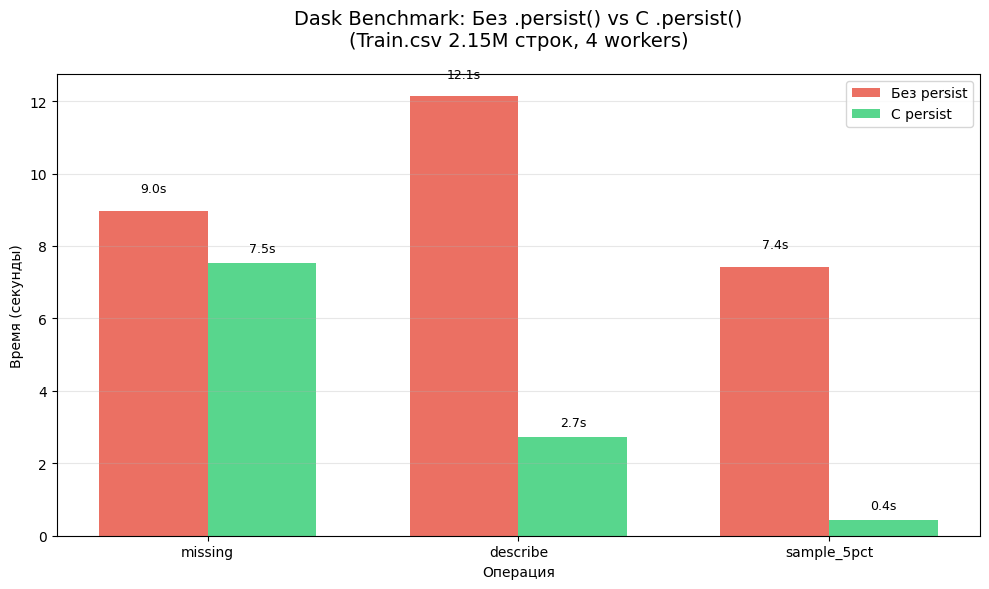

2026-03-03 23:57:20 DESKTOP-1G5G75V __main__[5660] INFO 🎉 ИТОГОВЫЙ SPEEDUP: 2.7x быстрее после .persist()!


In [1]:
# ====================== BENCHMARK DO / POSLE PERSIST ======================
import dask.dataframe as dd
from dask.distributed import Client
import pandas as pd
import time
import logging
import coloredlogs
import matplotlib.pyplot as plt

coloredlogs.install(level='INFO')
logger = logging.getLogger(__name__)

logger.info("🚀 Запуск benchmark: Dask без persist vs с persist")
client = Client(n_workers=4, threads_per_worker=2, memory_limit='4GB')  # потом заменишь на K8s

train_path = 'C:/vs_code_projects/distributed-churn-prediction/data/source/Train.csv'  # Или s3://bucket/Train.csv для cloud

# --------------------- 1. Без persist (ленивый режим) ---------------------
logger.info("=== ТЕСТ 1: Без .persist() ===")
ddf_no = dd.read_csv(train_path, blocksize='128MB', assume_missing=True)

operations = ['missing', 'describe', 'sample_5pct']

times_no = []
for i, op in enumerate(operations, 1):
    start = time.perf_counter()
    
    if op == 'missing':
        _ = (ddf_no.isnull().mean() * 100).compute()
    elif op == 'describe':
        _ = ddf_no.select_dtypes(include="number").describe().compute()
    elif op == 'sample_5pct':
        _ = ddf_no.sample(frac=0.05, random_state=42)[['REGULARITY', 'CHURN']].compute()
    
    elapsed = time.perf_counter() - start
    times_no.append(elapsed)
    logger.info(f"Операция {i}: {op} → {elapsed:.2f} сек")

# --------------------- 2. С .persist() ---------------------
logger.info("=== ТЕСТ 2: С .persist() ===")
start_persist = time.perf_counter()
ddf_yes = dd.read_csv(train_path, blocksize='128MB', assume_missing=True)
ddf_yes = ddf_yes.persist()                    # ← КЛЮЧЕВОЙ МОМЕНТ
persist_time = time.perf_counter() - start_persist

times_yes = []
for i, op in enumerate(operations, 1):
    start = time.perf_counter()
    
    if op == 'missing':
        _ = (ddf_yes.isnull().mean() * 100).compute()
    elif op == 'describe':
        _ = ddf_yes.select_dtypes(include="number").describe().compute()
    elif op == 'sample_5pct':
        _ = ddf_yes.sample(frac=0.05, random_state=42)[['REGULARITY', 'CHURN']].compute()
    
    elapsed = time.perf_counter() - start
    times_yes.append(elapsed)
    logger.info(f"Операция {i}: {op} → {elapsed:.2f} сек (после persist)")

# --------------------- Результаты ---------------------
df_bench = pd.DataFrame({
    'Operation': operations,
    'Без_persist_sec': times_no,
    'С_persist_sec': times_yes,
    'Speedup': [round(no/yes, 1) if yes > 0 else 0 for no, yes in zip(times_no, times_yes)]
})
df_bench.loc['TOTAL'] = ['persist_time', persist_time, 0, 0]  # для красоты

print("\n📊 BENCHMARK РЕЗУЛЬТАТЫ:")
print(df_bench.round(2))

# Сохраняем для портфолио
df_bench.to_csv('reports/benchmark_persist.csv', index=False)
logger.info("✅ Benchmark сохранён: reports/benchmark_persist.csv")

# --------------------- График speedup (убойно для README) ---------------------
plt.figure(figsize=(10, 6))
x = range(len(operations))
width = 0.35

plt.bar([i - width/2 for i in x], times_no, width, label='Без persist', color='#e74c3c', alpha=0.8)
plt.bar([i + width/2 for i in x], times_yes, width, label='С persist', color='#2ecc71', alpha=0.8)

plt.title('Dask Benchmark: Без .persist() vs С .persist()\n(Train.csv 2.15M строк, 4 workers)', fontsize=14, pad=20)
plt.ylabel('Время (секунды)')
plt.xlabel('Операция')
plt.xticks(x, operations)
plt.legend()
plt.grid(axis='y', alpha=0.3)

for i, (no, yes) in enumerate(zip(times_no, times_yes)):
    plt.text(i - width/2, no + 0.5, f'{no:.1f}s', ha='center', fontsize=9)
    plt.text(i + width/2, yes + 0.3, f'{yes:.1f}s', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('reports/benchmark_persist.png', dpi=300, bbox_inches='tight')
logger.info("✅ График speedup сохранён: reports/benchmark_persist.png")
plt.show()

# Финальный вывод для портфолио
total_speedup = round(sum(times_no) / sum(times_yes), 1)
logger.info(f"🎉 ИТОГОВЫЙ SPEEDUP: {total_speedup}x быстрее после .persist()!")